In [17]:
import imageio
import matplotlib.pyplot as plt
import netCDF4 as nc
import numpy as np
import os
import pandas as pd
import pygmt
import re
import rioxarray as rio
from scipy.stats import sem 
from scipy.ndimage import gaussian_filter
import shutil
import skimage
import subprocess
import sys
import xarray as xr
import xesmf as xe

In [18]:
# The PARED datapoints with their paleolatitude and paleolongitude, processed in processPARED.ipynb
pared = pd.read_csv('data/pared_time_pmag.csv')
pbdb = pd.read_csv('data/pbdb_time_pmag.csv')

# database = 'pbdb'
database = 'pared'

model = 'scotese' # 'scotese' or 'earthbyte'
if model == 'scotese':
    modelName = '2024-10-08_realigned_scotese_paleo_shallowSea'
    topoPath = f"{os.environ.get('HOME')}/Documents/Databases/Scotese_1deg_renamed"
    paleoLon, paleoLat = 'p_lng_sco', 'p_lat_sco'
    # paleoLon, paleoLat = 'p_lng_sco10', 'p_lat_sco10'
elif model == 'earthbyte':
    modelName = '2024-07-23_realigned_earthbyte_paleo_PaleomagRef'
    topoPath = f"{os.environ.get('HOME')}/Documents/Databases/Paleotopography_earthbyte/topos_filled_PaleomagRef"
    paleoLon, paleoLat = 'p_lng_pmag', 'p_lat_pmag'
    # paleoLon, paleoLat = 'p_lng_pmag10', 'p_lat_pmag10'

# Simple two column file that contains the preferred CO2 values for each time slice
# CO2File = f'preferredCO2_{modelName}_grossman2022.txt'
# CO2File = f'preferredCO2_2024-07-23_earthbyte_paleo_PaleomagRef_Scotese2021_paleotemps.txt'
CO2File = f'preferredCO2_2024-07-23_earthbyte_paleo_PaleomagRef_Merdith2024_pyscion.txt'
# CO2File = f'preferredCO2_2024-07-23_earthbyte_paleo_PaleomagRef_PhanDA_paleotemps.txt'

CO2name = 'pySCION'

co2s = pd.read_csv(CO2File,sep='\t',names=['co2'],index_col=[0])


/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_32209/1479358430.py:3: DtypeWarning: Columns (4,57,58,59) have mixed types. Specify dtype option on import or set low_memory=False.
  pbdb = pd.read_csv('data/pbdb_time_pmag.csv')


In [19]:
# age = 0

# climateData = f'../climateModelData/{modelName}_1120/{age}Ma_nc_outputs/gold_spn_av_0000003000_00.nc'
# climateData = xr.open_dataset(climateData)

# climateData['temp'].isel(time=0, depth=0).plot()

# temp = climateData['temp'].isel(time=0, depth=0)



In [20]:
def getSSTProbs(ds, varName = 'temp', tempAbsMin=18, tempMin=23, tempMax=28, tempAbsMax=32):
    """
    Get the fuzzy logic-like probabilities of SST with exponential decay from boundaries
    """
    # Assign all temp values between 23 and 28 °C to 1
    ds['tempProb'] = xr.where(
        (ds[varName] > tempMin) & (ds[varName] < tempMax),
        1,
        0
    )
    # Give an exponentially declining value from 29 to 31 °C to 0
    ds['tempProb'] = xr.where(
        (ds[varName] > tempMax) & (ds[varName] < tempAbsMax),
        np.exp(-((ds[varName] - tempMax) / 2)),
        ds['tempProb']
    )

    # Same for 20 to 23 °C
    ds['tempProb'] = xr.where(
        (ds[varName] > tempAbsMin) & (ds[varName] < tempMin),
        np.exp((ds[varName] - tempMin) / 2),
        ds['tempProb']
    )
    
    return ds

In [21]:
def find_nearest_valid(ds, lon, lat, OGlon, OGlat, var, radius=5.6125):
    """Find the nearest valid value in a dataset for a given variable and coordinates.
    Taken from https://github.com/pydata/xarray/issues/644"""
    # Select a subset of points within a certain radius
    subset = ds.sel(longitude=slice(lon-radius, lon+radius), latitude=slice(lat-radius, lat+radius))
    # Calculate the Euclidean distance to the points in the subset
    # dist = np.sqrt((subset.longitude - lon)**2 + (subset.latitude - lat)**2)
    dist = np.sqrt((subset.longitude - OGlon)**2 + (subset.latitude - OGlat)**2)
    # subset['landsea'].plot()

    # Create a new dataset that only includes valid values
    try:
        valid_subset = subset.where(~np.isnan(subset[var]), drop=True)
    except ValueError:
        print(f'No valid subset found at {lon}, {lat}')
        return None
    # Find the coordinates of the valid point with the smallest distance
    min_dist_coords = dist.where(dist == dist.where(~np.isnan(valid_subset[var])).min(), drop=True)
    # print(min_dist_coords)
    if len(min_dist_coords.longitude) > 1:
        # choose the one closest to the original coordinates
        lons = min_dist_coords.longitude.values
        lons = np.abs(lons - OGlon)
        nearest_lon = min_dist_coords.longitude.values[np.where(lons == lons.min())].item()
    else:
        nearest_lon = min_dist_coords.longitude.values.item()
    nearest_lat = min_dist_coords.latitude.values.item()
    # Select the nearest valid value
    # print(nearest_lon, nearest_lat)
    nearest = valid_subset.sel(longitude=nearest_lon, latitude=nearest_lat, method='nearest')
    # return nearest[var].to_dataframe().reset_index()
    return nearest[var].values.item(), nearest_lon, nearest_lat

In [22]:
def get_contours(ds, lons, lats, var):
    """
    Get contours from a dataset for given longitudes and latitudes and returns contours that trace around the vertices of the grid cells (rather than the mid points)

    This function uses the skimage.measure.find_contours function to find contours in the data.
    """
    # Check if the variable exists in the dataset
    if var not in ds:
        raise ValueError(f"Variable '{var}' not found in the dataset.")

    ## Create a new boolean DataArray with the same dimensions of ds but showing whether each pixel does or does not contain a reef
    #Initialize the 'isReef' variable with zeros in the same dimensions as the dataset
    new_da = xr.zeros_like(ds[var])

    # Convert the paleoreef points to a DataArray since that's easiest to work with the sel function
    points_ds = xr.Dataset({"longitude": ("points", lons), "latitude": ("points", lats),})

    # Also make sure lons are 0-360
    points_ds["longitude"] = points_ds["longitude"] % 360

    # Find the nearest grid cells for all points
    nearest_cells = new_da.sel(longitude=points_ds["longitude"], latitude=points_ds["latitude"], method="nearest")

    # Update the 'isReef' variable for all nearest cells
    new_da.loc[dict(longitude=nearest_cells['longitude'], latitude=nearest_cells['latitude'])] = 1

    contours = skimage.measure.find_contours(new_da.values, level=0.5)

    contour_index = 0
    for contour in contours:
        # Insert a new contour point into the corner of each cell
        i_skip = False
        i = 0
        max_range = len(contour)
        while i < max_range: # Loop over points in the contour
            if i_skip:
                i_skip = False
                continue
            
            y, x = contour[i]
            yp,xp = contour[i-1]
            if y != yp and x != xp:
                if y < yp and x < xp:
                    contour = np.insert(contour, i, [yp, x], axis=0)
                    max_range += 1
                    i_skip=True
                elif y < yp and x > xp:
                    contour = np.insert(contour, i, [y, xp], axis=0)
                    max_range += 1
                    i_skip=True
                elif y > yp and x > xp:
                    contour = np.insert(contour, i, [yp, x], axis=0)
                    max_range += 1
                    i_skip=True
                elif y > yp and x < xp:
                    contour = np.insert(contour, i, [y, xp], axis=0)
                    max_range += 1
                    i_skip=True
            i += 1
        
        # This bit moves the mini 'steps' that persist for more complex contours
        for i in range(len(contour)):
            y, x = contour[i]
            yp,xp = contour[i-1]
            try:
                yn,xn = contour[i+1]
            except:
                yn,xn = contour[0]
            if y % 1 == 0 and x % 1 == 0:
                if (yn < y and x < xp) or (yn > y and x > xp):
                    contour[i] = [yn, xp]
                if (y < yp and x < xn) or (y > yp and x > xn):
                    contour[i] = [yp, xn]
        
        # Insert back into the original array
        contours[contour_index] = contour
        contour_index += 1

    return contours

In [23]:
def animation(directory,name='animation.gif'):
    """ Makes an animation in numerical order from files in a directory. Just make sure the files are named with a number at the start, e.g. 1.png, 2.png, etc. """
    def extract_starting_integer(s):
        match = re.match(r'(\d+)', s)
        return int(match.group(1)) if match else float('inf')

    images = []
    for im in sorted(os.listdir(directory), key=extract_starting_integer):
        print(im)
        if not im.endswith('png'):
            continue
        images.append(imageio.v2.imread(f'{directory}/{im}'))
    imageio.mimwrite(f'{directory}/{name}',images, duration=500)

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_32209/3319181851.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2 = co2s.loc[age][0]


No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 36.5625, 30.470705032348633
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 14.0625, 41.552284240722656
No valid subset found at 8.4375, 41.552284240722656
No valid subset found at 19.6875, 41.552284240722656
No valid subset found at 30.9375, 24.9303169250488

/Users/jono/opt/anaconda3/envs/pyplasimGenie/lib/python3.11/site-packages/pygmt/clib/session.py:1655: RuntimeWarning: Grid may have irregular spacing in the 'latitude' dimension, but GMT only supports regular spacing. Calculated regular spacing 5.5873447541267645 is assumed in the 'latitude' dimension.
  matrix, region, inc = dataarray_to_matrix(grid)


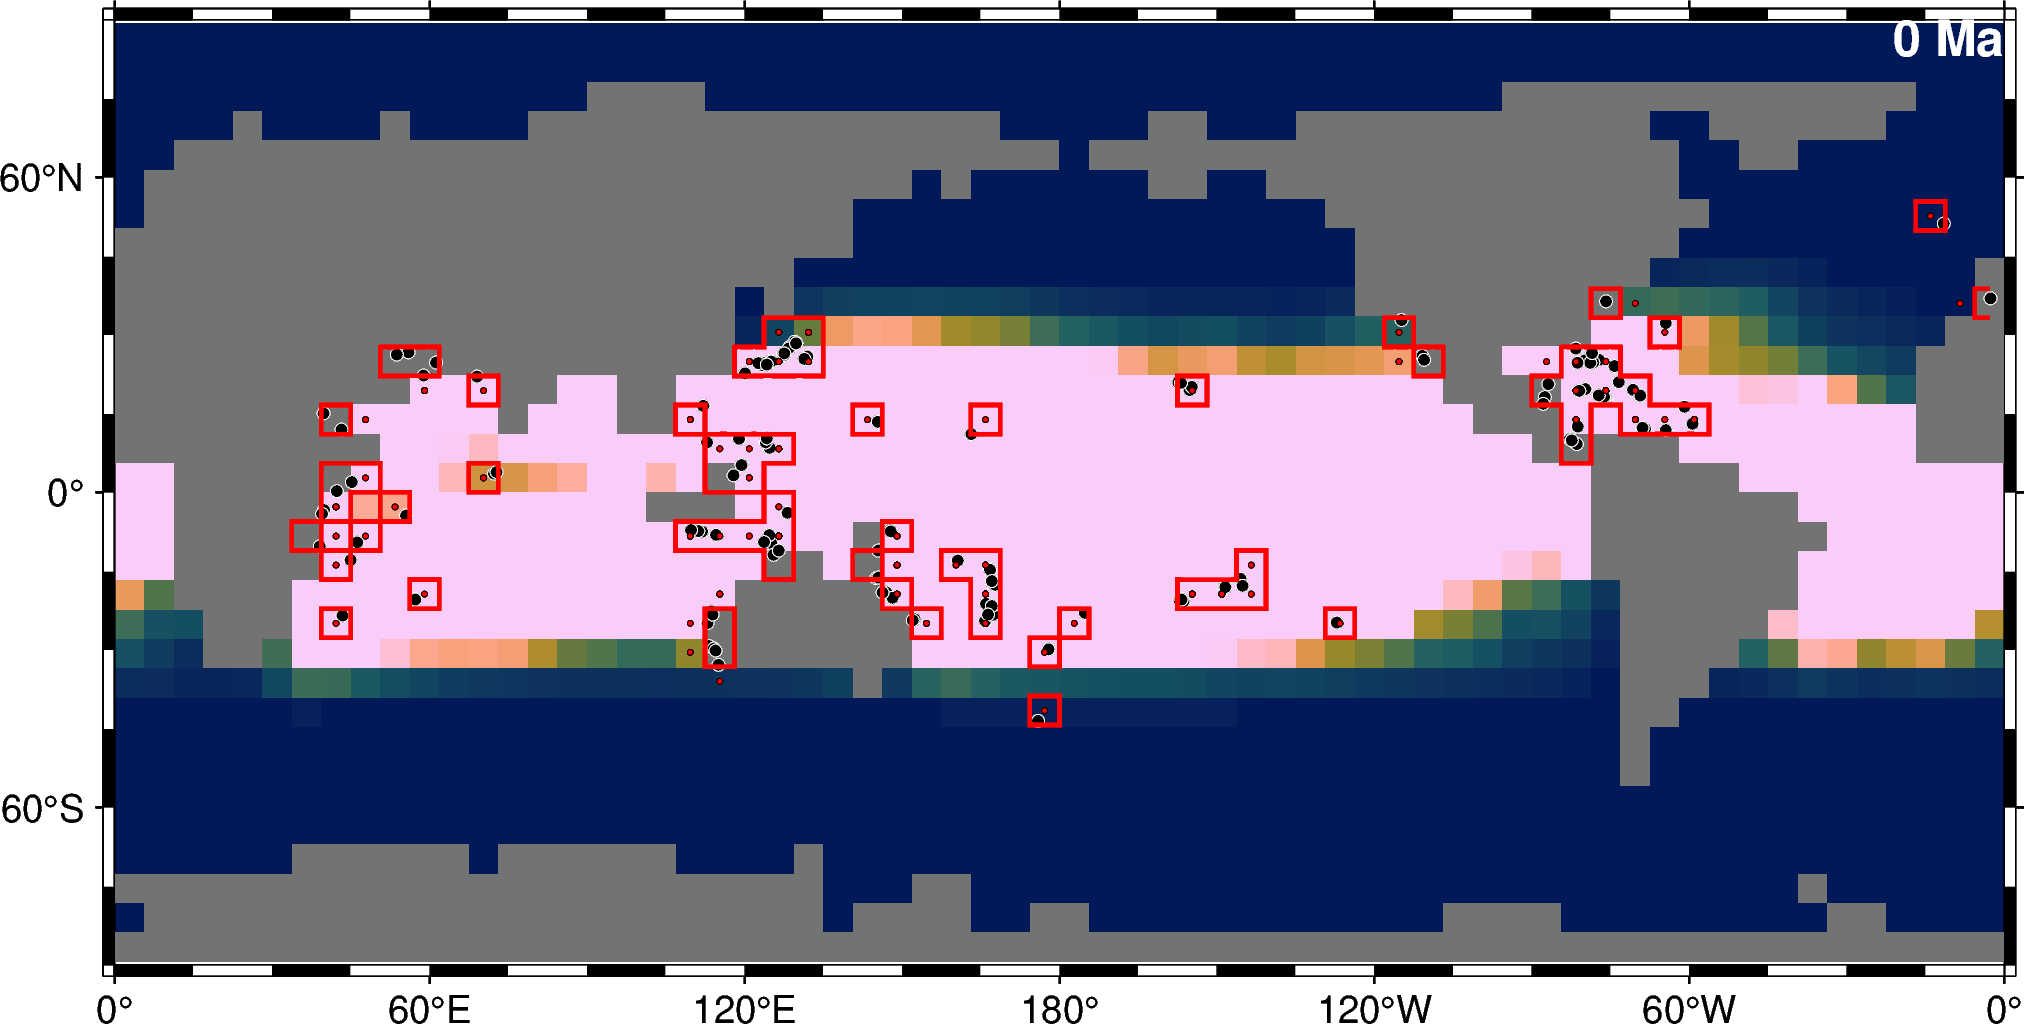

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_32209/3319181851.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2 = co2s.loc[age][0]


No valid subset found at 25.3125, 52.63585662841797
No valid subset found at 19.6875, 41.552284240722656
No valid subset found at 19.6875, 47.093719482421875
No valid subset found at 36.5625, 13.849992752075195
No valid subset found at 47.8125, 24.930316925048828
No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 14.0625, 47.093719482421875
No valid subset found at 36.5625, 19.39009666442871
No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 2.8125, 41.552284240722656
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 14.0625, 47.093719482421875
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 25.3125, 47.093719482421875
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 36.5625, 24.930316925048828
No valid subset found at 36.5625, 19.390096664428

/Users/jono/opt/anaconda3/envs/pyplasimGenie/lib/python3.11/site-packages/pygmt/clib/session.py:1655: RuntimeWarning: Grid may have irregular spacing in the 'latitude' dimension, but GMT only supports regular spacing. Calculated regular spacing 5.5873447541267645 is assumed in the 'latitude' dimension.
  matrix, region, inc = dataarray_to_matrix(grid)


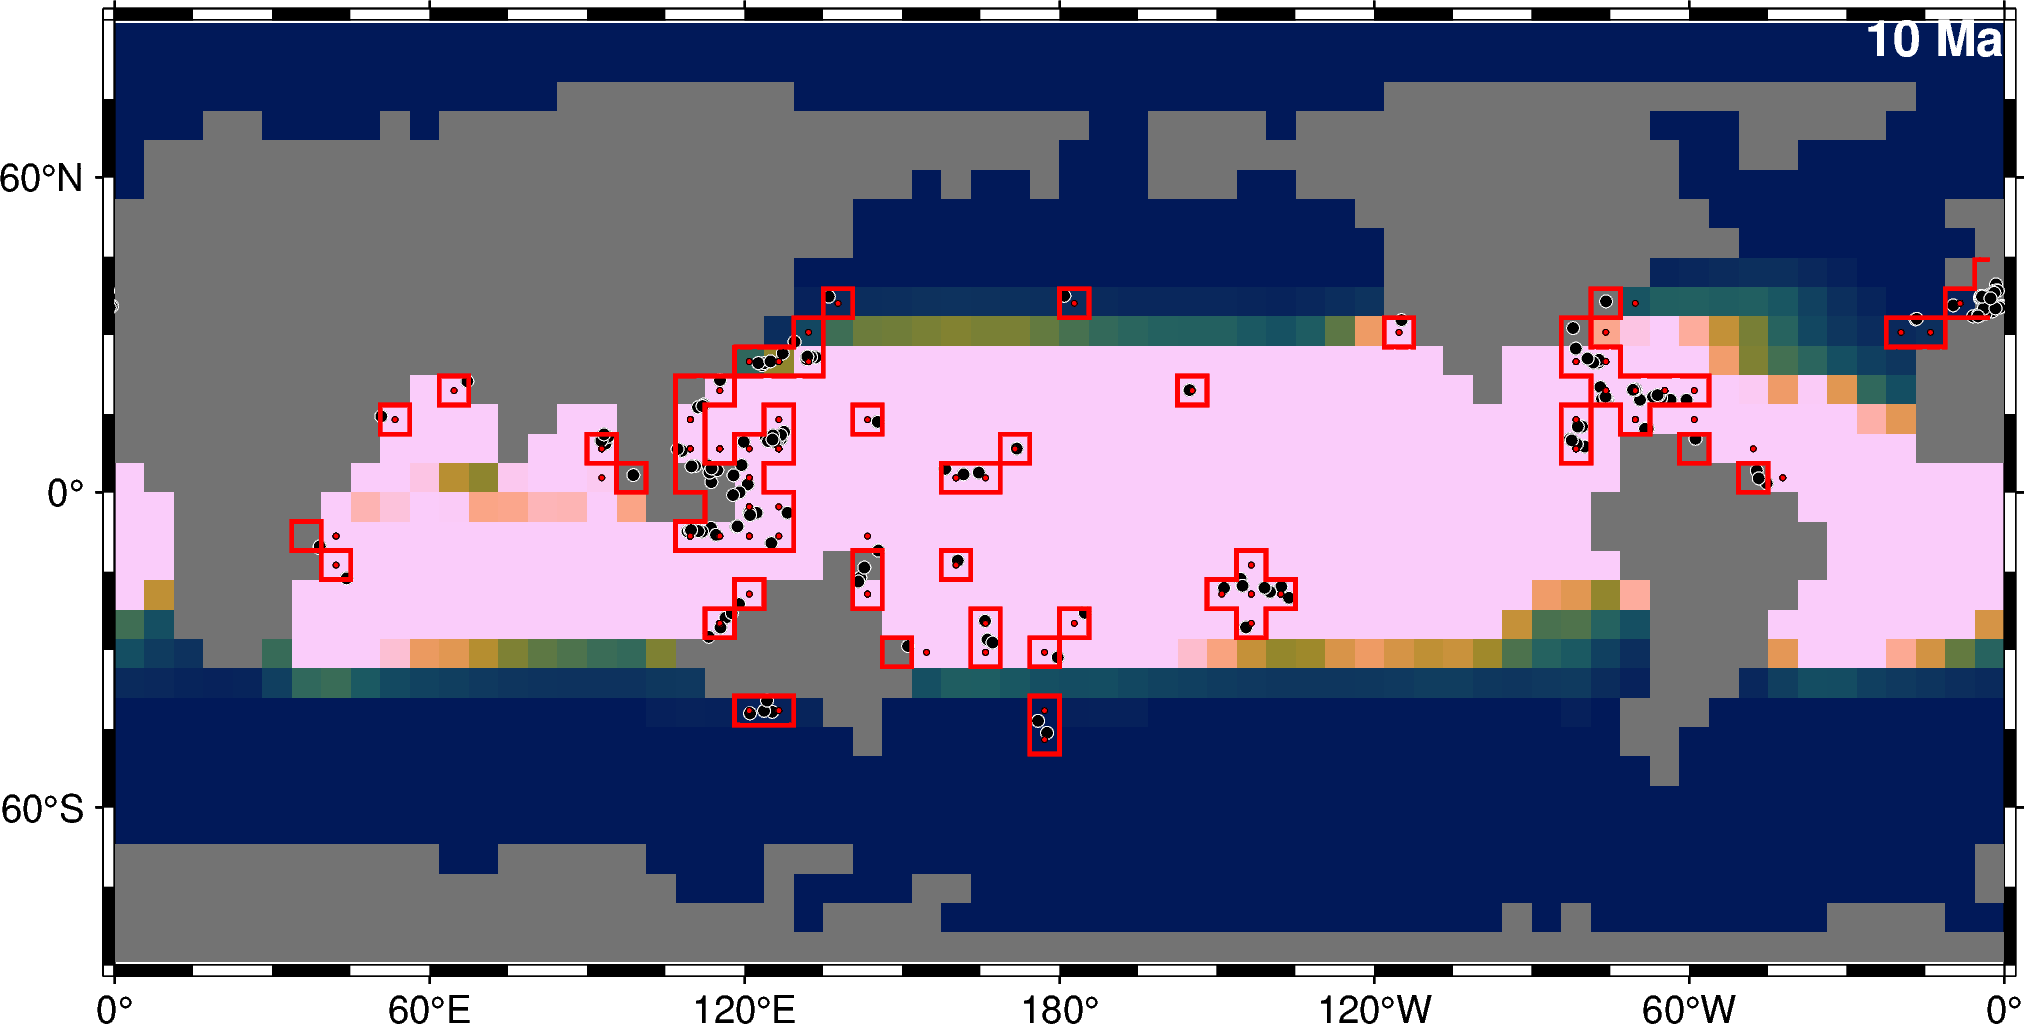

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_32209/3319181851.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2 = co2s.loc[age][0]


No valid subset found at 47.8125, 30.470705032348633
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 42.1875, 30.470705032348633
No valid subset found at 47.8125, 24.930316925048828
No valid subset found at 47.8125, 24.930316925048828
No valid subset found at 42.1875, 30.470705032348633
No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 47.8125, 30.470705032348633
No valid subset found at 36.5625, 41.552284240722656
No valid subset found at 30.9375, 36.011329650878906
No valid subset found at 30.9375, 24.930316925

/Users/jono/opt/anaconda3/envs/pyplasimGenie/lib/python3.11/site-packages/pygmt/clib/session.py:1655: RuntimeWarning: Grid may have irregular spacing in the 'latitude' dimension, but GMT only supports regular spacing. Calculated regular spacing 5.5873447541267645 is assumed in the 'latitude' dimension.
  matrix, region, inc = dataarray_to_matrix(grid)


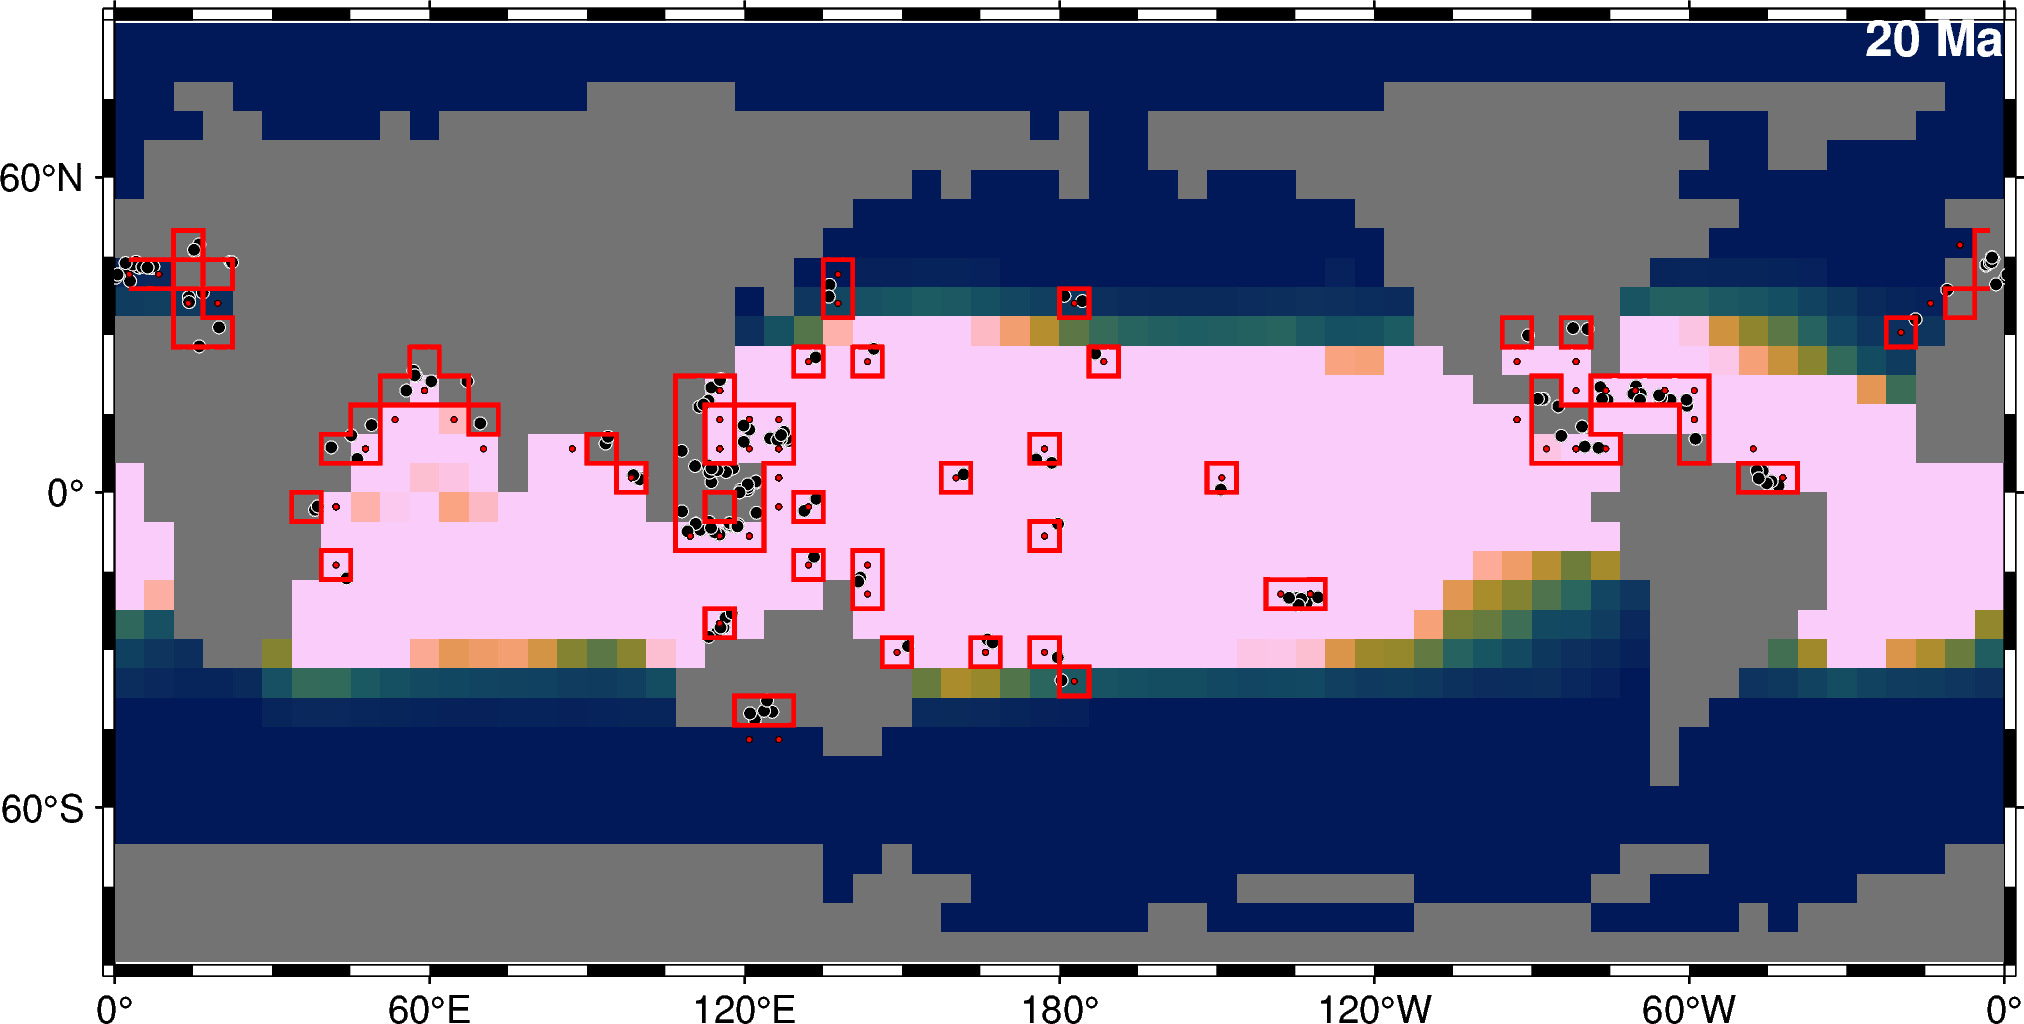

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_32209/3319181851.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2 = co2s.loc[age][0]


No valid subset found at 25.3125, 36.011329650878906
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 25.3125, 36.011329650878906
No valid subset found at 47.8125, 30.470705032348633
No valid subset found at 47.8125, 24.930316925048828
No valid subset found at 47.8125, 24.930316925048828
No valid subset found at 47.8125, 30.470705032348633
No valid subset found at 30.9375, 24.930316925048828
No valid subset found at 42.1875, 30.470705032348633
No valid subset found at 47.8125, 24.930316925048828
No valid subset found at 47.8125, 24.930316925048828
No valid subset found at 42.1875, 30.470705032348633
No valid subset found at 30.9375, 36.011329650878906


/Users/jono/opt/anaconda3/envs/pyplasimGenie/lib/python3.11/site-packages/pygmt/clib/session.py:1655: RuntimeWarning: Grid may have irregular spacing in the 'latitude' dimension, but GMT only supports regular spacing. Calculated regular spacing 5.5873447541267645 is assumed in the 'latitude' dimension.
  matrix, region, inc = dataarray_to_matrix(grid)


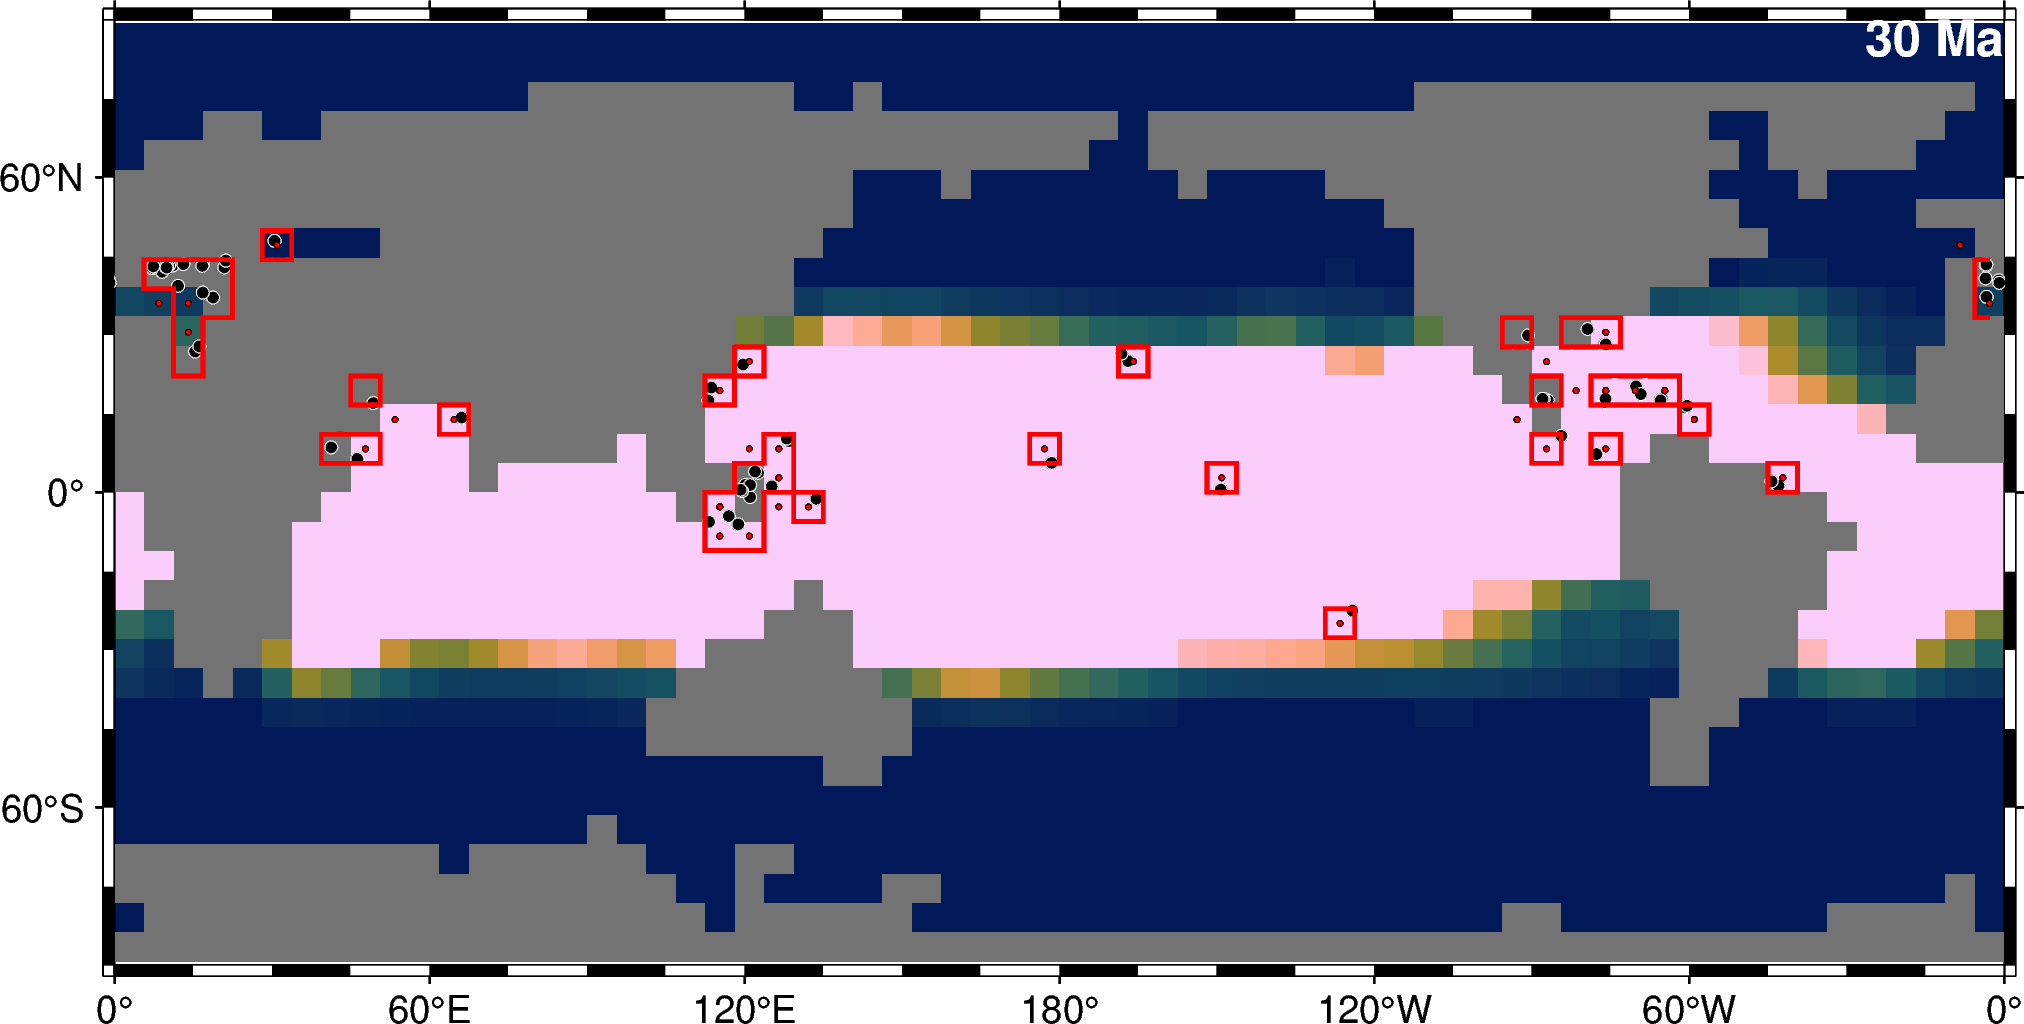

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_32209/3319181851.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2 = co2s.loc[age][0]


No valid subset found at 14.0625, 41.552284240722656
No valid subset found at 357.1875, 41.552284240722656
No valid subset found at 14.0625, 41.552284240722656
No valid subset found at 14.0625, 47.093719482421875
No valid subset found at 357.1875, 41.552284240722656
No valid subset found at 357.1875, 41.552284240722656
No valid subset found at 14.0625, 41.552284240722656
No valid subset found at 14.0625, 47.093719482421875
No valid subset found at 357.1875, 41.552284240722656
No valid subset found at 14.0625, 41.552284240722656
No valid subset found at 8.4375, 41.552284240722656
No valid subset found at 14.0625, 41.552284240722656
No valid subset found at 8.4375, 41.552284240722656
No valid subset found at 357.1875, 41.552284240722656
No valid subset found at 357.1875, 36.011329650878906
No valid subset found at 19.6875, 41.552284240722656
No valid subset found at 8.4375, 41.552284240722656
No valid subset found at 30.9375, 47.093719482421875
No valid subset found at 357.1875, 41.55228

/Users/jono/opt/anaconda3/envs/pyplasimGenie/lib/python3.11/site-packages/pygmt/clib/session.py:1655: RuntimeWarning: Grid may have irregular spacing in the 'latitude' dimension, but GMT only supports regular spacing. Calculated regular spacing 5.5873447541267645 is assumed in the 'latitude' dimension.
  matrix, region, inc = dataarray_to_matrix(grid)


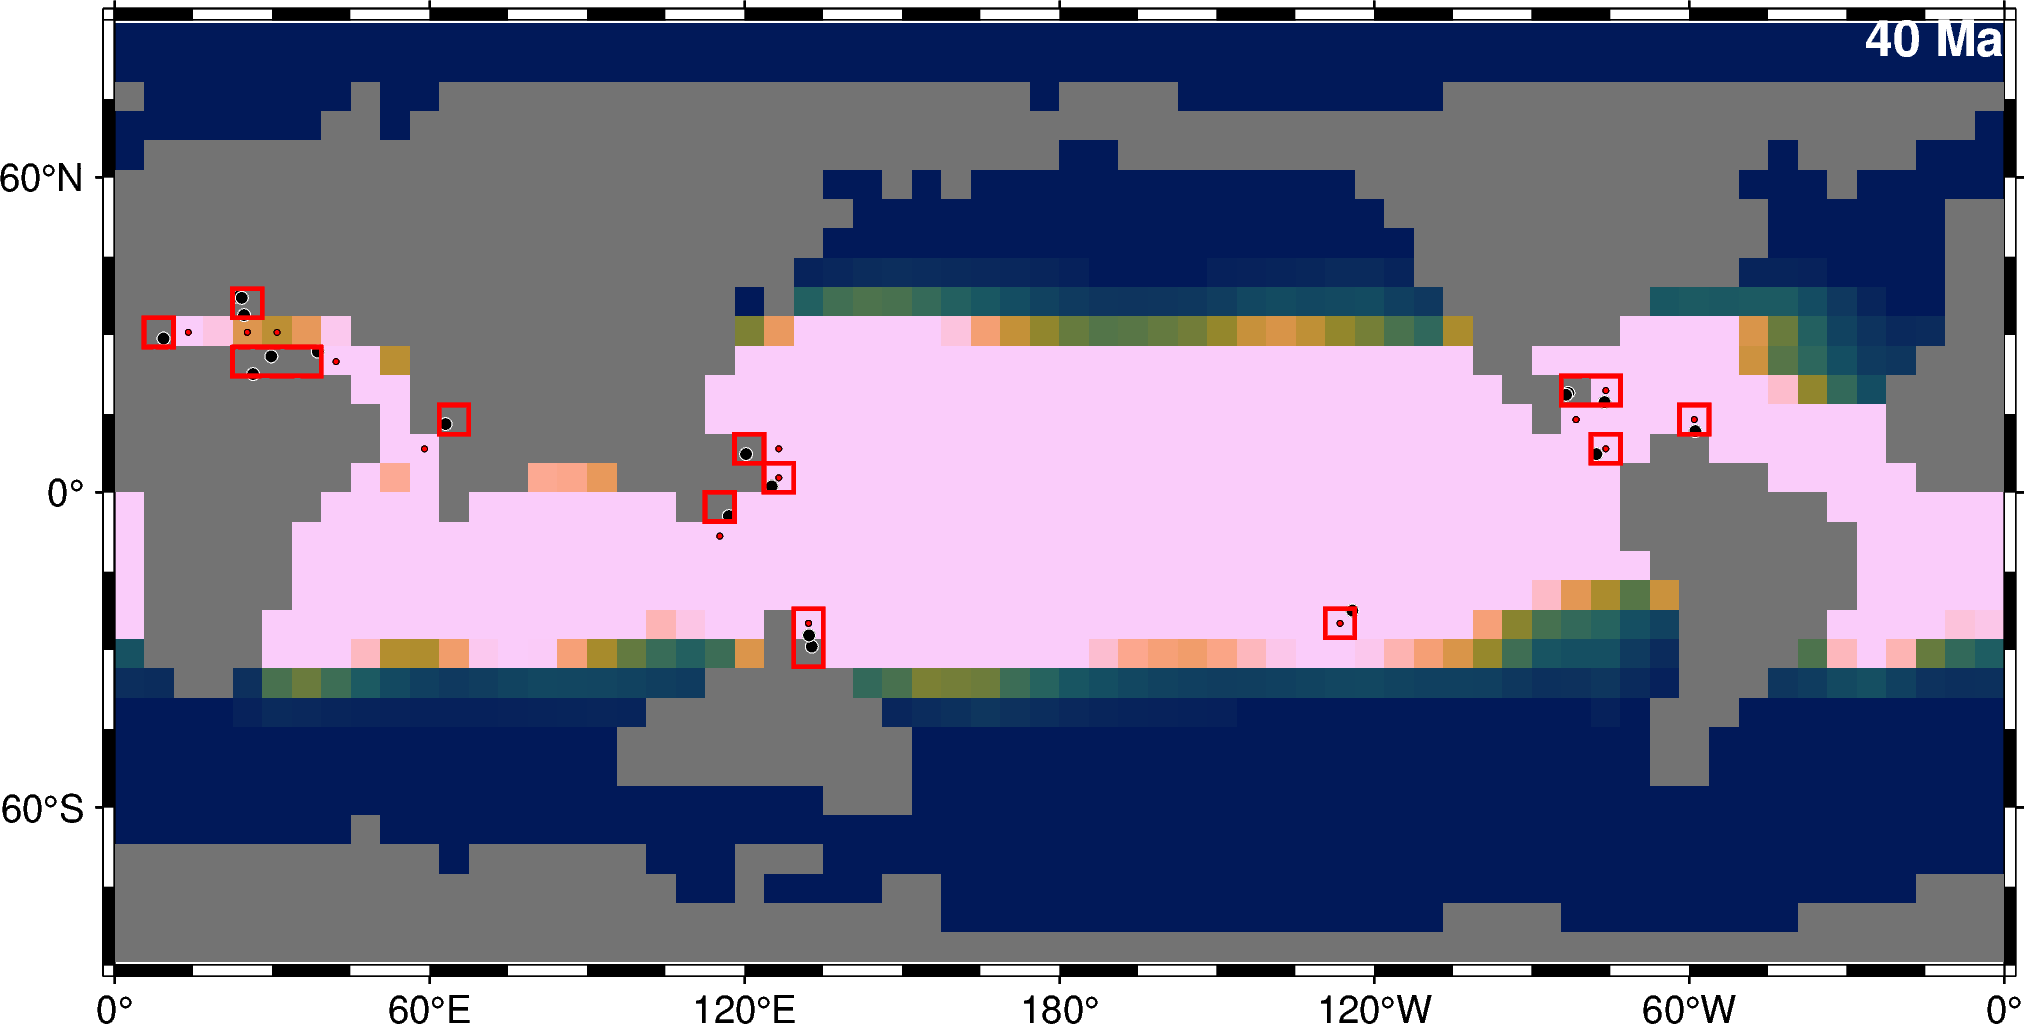

/var/folders/hp/drslwmbd3r7502z1wfd_w7bw0000gr/T/ipykernel_32209/3319181851.py:17: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  co2 = co2s.loc[age][0]


FileNotFoundError: [Errno 2] No such file or directory: '/Users/jono/Library/CloudStorage/OneDrive-TheUniversityofSydney(Staff)/paleoReef/climateModelData/2024-10-08_realigned_scotese_paleo_shallowSea_280/50Ma_nc_outputs/gold_spn_av_0000003000_00.nc'

In [ ]:
# Plot the SST probabilities
proj="Q16" # Cylindrical equidistant projection
# proj="H16"
region='g' # d = Global region

pygmt.makecpt(cmap='batlow', reverse=False, series=[0,1], background=True, output='reefProbSST.cpt')
pygmt.makecpt(cmap='gray', series=[-10,10], background=False, output='landGray.cpt', reverse=True)


figFolder = f'SST_probs_{model}'
if os.path.exists(figFolder):
    shutil.rmtree(figFolder)
os.makedirs(figFolder)

for age in np.arange(0, 260,10):
# for age in [220]:
    co2 = co2s.loc[age][0]

    climateData = f'../climateModelData/{modelName}_{co2}/{age}Ma_nc_outputs/gold_spn_av_0000003000_00.nc'
    climateData = xr.open_dataset(climateData)
    
    # Get the SST probabilities
    climateData = getSSTProbs(climateData, varName='temp', tempAbsMin=14, tempMin=22, tempMax=30, tempAbsMax=35)
    climateData['landsea'] = xr.where(climateData['bathymetry'] > 0, 0., 1)
    
    # Move each point to center of the grid cell then find nearest ocean cell for those that are on land
    climateData['landNAN'] = climateData['landsea'].where(climateData['landsea'] == 0) # near variable where land values are NaN (instead of 1)

    if database == 'pbdb':
        df = pbdb[(pbdb['mid'] > age-5) & (pbdb['mid'] < age+5)].copy()
    elif database == 'pared':
        # df = pared[(pared['mid'] > age-5) & (pared['mid'] < age+5) & (pared['tropical'] != 2)].copy()
        # Where part of the age range between bottom and top are within +/- 5 Ma of age
        # df = pared[((pared['bottom'] >= age-5) & (pared['bottom'] <= age+5)) | ((pared['top'] >= age-5) & (pared['top'] <= age+5)) & (pared['tropical'] != 2)].copy()
        df = pared[((pared['bottom'] >= age-5) & (pared['top'] <= age+5))].copy()

    if df.empty:
        continue
    select = pd.DataFrame({
        # 'longitude': np.where(df[paleoLon] >= 0, df[paleoLon], df[paleoLon] + 360),
        'longitude': df[paleoLon],
        'latitude': df[paleoLat]
    })

    select['longitude'] = select['longitude'].where(select['longitude'] >= 0, select['longitude'] + 360) # convert to 0-360
    
    # Get cell coordinates of each reef point then move any points on land to the nearest ocean cell
    reefLandsea = []
    nearestValid = []
    for index, row in select.iterrows():
        # This will get the coords of the cell nearest to the reef point and whether the cell is land or ocean
        landseaVal = climateData['landNAN'].sel(longitude=row['longitude'], latitude=row['latitude'], method='nearest')
        reefLandsea.append((landseaVal.values.item(), landseaVal.longitude.values.item(), landseaVal.latitude.values.item()))

        if np.isnan(landseaVal.values.item()):
            # Find the nearest ocean cell - this also needs the non-interpolated reef coords as a 'tie breaker' when the nan cell is between two ocean cells
            nearest = find_nearest_valid(climateData, landseaVal.longitude.values.item(), landseaVal.latitude.values.item(), row['longitude'], row['latitude'], 'landNAN', radius=6)
        else:
            nearest = (np.nan, np.nan, np.nan) # return nans if not within the defined radius
        nearestValid.append(nearest)
    
    # Now put the nearest coords and land/ocean values into the select dataframe
    select['reefLandsea'] = [landseaVal[0] if landseaVal is not None else np.nan for landseaVal in reefLandsea]
    select['realignedLon'] = [landseaVal[1] if landseaVal is not None else np.nan for landseaVal in reefLandsea]
    select['realignedLat'] = [landseaVal[2] if landseaVal is not None else np.nan for landseaVal in reefLandsea]
    select['nearestLandsea'] = [item[0] if item is not None else np.nan for item in nearestValid]
    select['nearestLon'] = [item[1] if item is not None else np.nan for item in nearestValid]
    select['nearestLat'] = [item[2] if item is not None else np.nan for item in nearestValid]

    # Have a final set of columns that is either the cell coord that the reef point is in or the one that is nearest to it
    select = select[(select['nearestLandsea'] == 0) | (select['reefLandsea'] == 0)]
    select['finalLon'] = np.where(select['nearestLandsea'] == 0, select['nearestLon'], select['realignedLon'])
    select['finalLat'] = np.where(select['nearestLandsea'] == 0, select['nearestLat'], select['realignedLat'])

    # Plot the SST probabilities
    fig = pygmt.Figure()
    fig.grdimage(
        grid=climateData['tempProb'].isel(time=0, depth=0),
        projection=proj,
        region=region,
        frame=True,
        cmap='reefProbSST.cpt'
    )

    fig.grdimage(climateData['landsea'], projection=proj, region=region, cmap='landGray.cpt', nan_transparent='+z0')
    fig.plot(x=select['longitude'], y=select['latitude'], style="c0.11c", pen="0.07p,white", fill="black", label='PARED Paleoreefs', region=region)
    fig.plot(x=select['finalLon'], y=select['finalLat'], style="c0.05c", pen="0.01p,black", fill="red", label='Paleoreef Cells', region=region)

    # Get contours to draw around cells
    contours = get_contours(climateData, select['realignedLon'], select['realignedLat'], 'landsea')

    # Plot each contour 
    for contour in contours:
        # Interpolate the contour/pixel coordinates into lats/lons
        ys, xs = contour[:, 0], contour[:, 1]
        lon = climateData['longitude'].values
        lat = climateData['latitude'].values
        contour_lon = np.interp(xs, np.arange(len(lon)), lon)
        contour_lat = np.interp(ys, np.arange(len(lat)), lat)
        
        # Plot the outline
        fig.plot(x=contour_lon, y=contour_lat, pen="1p,red", projection=proj, region=region)

    fig.text(
        position="TR",
        text=f"{age} Ma",
        font="12p,Helvetica-Bold,white"
    )
    fig.show()
    fig.savefig(f"{figFolder}/{age}Ma_SSTprobs.png")

    # Get the probability at each reef point
    grid=climateData['tempProb'].isel(time=0, depth=0)
    gridSST = climateData['temp'].isel(time=0, depth=0)
    # Initialise a new column for the probabilities
    select['prob'] = np.nan
    # Loop over the reef points and get the probability at each one
    for lon,lat in zip(select['finalLon'], select['finalLat']):
        # Get the probability at the reef point
        prob = grid.sel(longitude=lon, latitude=lat, method='nearest')
        # Add the probability to the dataframe
        select.loc[(select['finalLon'] == lon) & (select['finalLat'] == lat), 'prob'] = prob.values.item()

        # Add the sst  to the dataframe
        sst = gridSST.sel(longitude=lon, latitude=lat, method='nearest')
        # Ensure that sst.values contains only one element before calling .item()
        if sst.values.size == 1:
            select.loc[(select['finalLon'] == lon) & (select['finalLat'] == lat), 'sst'] = sst.values.item()
        else:
            raise ValueError(f"Unexpected size of sst.values: {sst.values.size}. Expected size 1.")
    # Save the dataframe to a csv file
    folder = f'reefPoints_SSTonly_{modelName}_{CO2name}'
    if not os.path.exists(folder):
        os.makedirs(folder)
    
    select.to_csv(f"{folder}/SST_probs_{age}Ma.csv", index=False)

animation(figFolder, name='SST_probs.gif')


# Probability comparison plot


In [27]:
scoteseData = f'reefPoints_SSTonly_scotese_2024-10-08_realigned_scotese_paleo_shallowSea_{CO2name}'
earthbyteData = f'reefPoints_SSTonly_earthbyte_2024-07-23_realigned_earthbyte_paleo_PaleomagRef_{CO2name}'

probs = {}
sems = {}
num = {}
percent_above_threshold = {}
threshold = 0.5
for age in np.arange(0,260,10):
    # scoteseDS = xr.open_dataset(f'{scoteseData}/{age}.nc')
    # pmagDS = xr.open_dataset(f'{earthbyteData}/{age}.nc')

    try:
        selectPmag = pd.read_csv(f'{earthbyteData}/SST_probs_{age}Ma.csv')
        selectScotese = pd.read_csv(f'{scoteseData}/SST_probs_{age}Ma.csv')

        # Remove duplicate finalLon and finalLat values
        selectPmag = selectPmag.drop_duplicates(subset=['finalLon', 'finalLat']).reset_index(drop=True)
        selectScotese = selectScotese.drop_duplicates(subset=['finalLon', 'finalLat']).reset_index(drop=True)
    except Exception as e:
        print(e)
        num[age] = (0, 0)
        continue


    Sprobs = []
    Pprobs = []
    for i in range(len(selectPmag)):
        Plat = selectPmag['finalLat'][i]
        Plon = selectPmag['finalLon'][i]
        Pprob = selectPmag['prob'][i]

        # pmagDS['wmean'] = xr.where(pmagDS['wmean']>1200,1200,pmagDS['wmean'])
        # Pprob = pmagDS['wmean'].sel(lon=Plon, lat=Plat, method='nearest').values.item()
        Pprobs.append(Pprob)
    for i in range(len(selectScotese)):
        Slat = selectScotese['finalLat'][i]
        Slon = selectScotese['finalLon'][i]  
        Sprob = selectScotese['prob'][i]
        # scoteseDS['wmean'] = xr.where(scoteseDS['wmean']>1200,1200,scoteseDS['wmean'])   
        # Sprob = scoteseDS['wmean'].sel(lon=Slon, lat=Slat, method='nearest').values.item()  
        Sprobs.append(Sprob)

    probs[age] = (np.mean(Sprobs), np.mean(Pprobs))
    sems[age] = (sem(Sprobs), sem(Pprobs))
    num[age] = (len(Sprobs), len(Pprobs))
    percent_above_threshold[age] = (np.sum(np.array(Sprobs) > threshold)/len(Sprobs), np.sum(np.array(Pprobs) > threshold)/len(Pprobs))


[Errno 2] No such file or directory: 'reefPoints_SSTonly_earthbyte_2024-07-23_realigned_earthbyte_paleo_PaleomagRef_pySCION/SST_probs_0Ma.csv'
[Errno 2] No such file or directory: 'reefPoints_SSTonly_earthbyte_2024-07-23_realigned_earthbyte_paleo_PaleomagRef_pySCION/SST_probs_10Ma.csv'
[Errno 2] No such file or directory: 'reefPoints_SSTonly_earthbyte_2024-07-23_realigned_earthbyte_paleo_PaleomagRef_pySCION/SST_probs_20Ma.csv'
[Errno 2] No such file or directory: 'reefPoints_SSTonly_earthbyte_2024-07-23_realigned_earthbyte_paleo_PaleomagRef_pySCION/SST_probs_30Ma.csv'
[Errno 2] No such file or directory: 'reefPoints_SSTonly_earthbyte_2024-07-23_realigned_earthbyte_paleo_PaleomagRef_pySCION/SST_probs_40Ma.csv'
[Errno 2] No such file or directory: 'reefPoints_SSTonly_earthbyte_2024-07-23_realigned_earthbyte_paleo_PaleomagRef_pySCION/SST_probs_50Ma.csv'
[Errno 2] No such file or directory: 'reefPoints_SSTonly_earthbyte_2024-07-23_realigned_earthbyte_paleo_PaleomagRef_pySCION/SST_probs_60M

IndexError: list index out of range

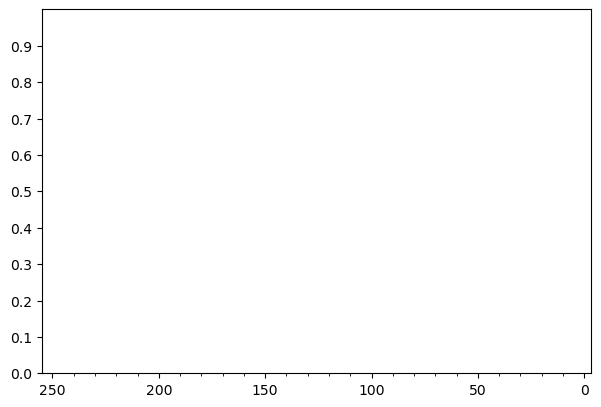

In [28]:
mm = 1/25.4  # mm in inches
fig, ax = plt.subplots(figsize=(180*mm,120*mm))

# Set Y-axis limits
ax.set_ylim(0, 1)
ax.set_xlim(255,-3.2)

# Add tick marks for the Y-axis
ax.set_yticks(np.arange(0, 1, 0.1))
ax.set_xticks(np.arange(0, 251, 50))

# ax.set_yticks(np.arange(15, 29.5, 1), minor=True)
ax.set_xticks(np.arange(0, 251, 10), minor=True)

# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

ax.plot(probs.keys(), list(zip(*probs.values()))[1], linewidth=1.2, color='blue', label='Paleogeography Model #1 (Cao2017)')
ax.errorbar(probs.keys(), list(zip(*probs.values()))[1], yerr=list(zip(*sems.values()))[1], linewidth=1.2, color='blue', elinewidth=1, markeredgewidth=1)

ax.plot(probs.keys(), list(zip(*probs.values()))[0], linewidth=1.2, color='red', label='Paleogeography Model #2 (Scotese PALEOMAP)')
ax.errorbar(probs.keys(), list(zip(*probs.values()))[0], yerr=list(zip(*sems.values()))[0], linewidth=1.2, color='red', elinewidth=1, markeredgewidth=1)

ax.set_xlabel('Age (Ma)')
ax.set_ylabel('Average Reef Suitability')

# Hide the right and top spines
ax.spines[['right', 'top']].set_visible(False)

# Secondary axis
ax2 = ax.twinx()
ax2.set_ylim(0, 100)
ax2.set_yticks(np.arange(0, 81, 10))
ax2.set_ylabel('Number of Data Points')
ax2.hist(list(num.keys()), bins=np.arange(-5, 260, 10), weights=list(zip(*num.values()))[1], color='blue', alpha=0.5, label='Paleogeography Model #1 (Cao2017)')
ax2.hist(list(num.keys()), bins=np.arange(-5, 260, 10), weights=list(zip(*num.values()))[0], color='red', alpha=0.5, label='Paleogeography Model #2 (Scotese PALEOMAP)')

ax2.plot([], [], color='black', linestyle=':', label='No. of Data Points')


# ax2.plt()

ax.legend(loc='upper right', ncol=1, frameon=False)
ax2.legend(loc='lower center', ncol=1, frameon=False)

fig.savefig(f'probabilityComparison_{CO2name}.png',dpi=300,transparent=True)


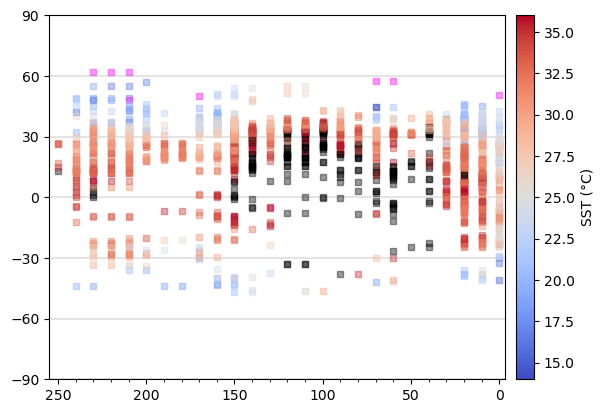

In [ ]:
# Plot the latitudinal distribution of reefs through time
fig, ax = plt.subplots(figsize=(180*mm,120*mm))
# Set Y-axis limits
ax.set_ylim(-90, 90)
ax.set_xlim(255,-3.2)
# Add tick marks for the Y-axis
ax.set_yticks(np.arange(-90, 91, 30))
ax.set_xticks(np.arange(0, 251, 50))
ax.set_xticks(np.arange(0, 251, 10), minor=True)
# Customize grid appearance
ax.xaxis.remove_overlapping_locs = False
ax.yaxis.remove_overlapping_locs = False

# Set haroizontal grid lines
ax.yaxis.grid(True, which='major', color='gray', linestyle='-', linewidth=0.3)

for age in np.arange(0, 260, 10):
    try:
        if model == 'earthbyte':
            select = pd.read_csv(f'reefPoints_SSTonly_2024-07-23_realigned_earthbyte_paleo_PaleomagRef/SST_probs_{age}Ma.csv')
        elif model == 'scotese':
            select = pd.read_csv(f'reefPoints_SSTonly_2024-10-08_realigned_scotese_paleo_shallowSea/SST_probs_{age}Ma.csv')
    except Exception as e:
        print(e)
        # num[age] = (0, 0)
        continue
    # make a color map based on the probability
    cmap = plt.get_cmap('coolwarm')

    # Make the low extreme of the color map bright pink and the high extreme black
    cmap.set_under('magenta')
    cmap.set_over('black')

    # Normalize the color based on the probability
    norm = plt.Normalize(14, 36)

    
    for row in select.iterrows():
        lat = row[1]['latitude']
        color = row[1]['sst']
        color = cmap(norm(color))
        ax.plot(age, lat, color=color, marker='s', markersize=4, alpha=0.4)
    # ax.plot(age, selectPmag['finalLat'], style="c0.05c", pen="0.01p,black")
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)  # Create a ScalarMappable object
fig.colorbar(sm, ax=ax, label='SST (°C)', orientation='vertical', pad=0.02)

fig.savefig(f'latDistribution_{modelName}_{CO2name}.png',dpi=300,transparent=True)




In [ ]:
color

(0.7743368501529412, 0.19975926804705882, 0.2025345544352941, 1.0)